# 03b — Feature Engineering : dataset enrichi Nayaar

Construit la **Nayaar Knowledge Base** à partir de `nayaar_clean.csv` (données)
et `notes_vocabulary.json` (connaissance métier validée manuellement).

**Entrées** :
- `data/processed/nayaar_clean.csv`
- `data/processed/notes_vocabulary.json`

**Sortie** : `data/processed/nayaar_knowledge_base.csv`

Features produites (uniquement celles-ci) :

| Feature | Origine |
|---|---|
| `notes_categories` | catégories olfactives présentes, dérivées du vocabulaire |
| `famille` | catégorie dominante, règles de départage explicites |
| `winter_score` / `spring_score` / `summer_score` / `autumn_score` | moyenne des scores saisonniers des notes reconnues |
| `day_score` / `night_score` | moyenne des scores jour/nuit des notes reconnues |
| `profil` | mots-clés explicites (nom + description) en priorité, sinon moyenne des tendances des notes |
| `concentration` | regex sur le nom (EDT/EDP/Parfum/Cologne/Attar...), vide si non détecté |
| `profil_text` | texte enrichi pour les futurs embeddings |

Chaque feature a sa cellule de validation (distribution + 5 exemples concrets),
et chaque score numérique reste **traçable** : on peut toujours retrouver quelles
notes ont produit quelle valeur (fonctions d'explication dédiées).

⚠️ **Aucun appel GPT.** Toute la logique est faite de règles explicites,
conformément à `CLAUDE.md` (l'IA ne décide jamais seule d'une recommandation).

In [1]:
import json
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CHEMIN_DATASET_PROPRE = "../processed/nayaar_clean.csv"
CHEMIN_VOCABULAIRE = "../processed/notes_vocabulary.json"
CHEMIN_SORTIE = "../processed/nayaar_knowledge_base.csv"

sns.set_theme(style="whitegrid")


## 1. Chargement des données

In [2]:
df = pd.read_csv(CHEMIN_DATASET_PROPRE, encoding="utf-8")
df["notes_list"] = df["notes_list"].apply(json.loads)

with open(CHEMIN_VOCABULAIRE, encoding="utf-8") as f:
    vocabulaire = json.load(f)

NOTES_VOCAB = vocabulaire["notes"]  # {note_canonique: {categorie, saisons, moment, profil, ...}}
MAPPING_NORMALISATION = vocabulaire["mapping_normalisation"]

print(f"Parfums : {len(df)}")
print(f"Notes dans le vocabulaire : {len(NOTES_VOCAB)}")


Parfums : 2191
Notes dans le vocabulaire : 333


## 2. Fonction commune : notes reconnues d'un parfum

Toutes les features de scoring reposent sur la même étape : associer les
notes brutes d'un parfum aux entrées du vocabulaire (même mapping de
normalisation que le notebook 03a, réutilisé ici tel quel pour rester
cohérent). Les notes non présentes dans le vocabulaire (trop rares, ou
écartées comme bruit lors du 03a) sont ignorées — et on garde une trace de
combien de notes ont réellement été reconnues, pour pouvoir toujours
expliquer un score.

In [3]:
def notes_reconnues(notes_brutes):
    """
    Normalise les notes brutes d'un parfum (même mapping que le notebook 03a)
    et ne garde que celles présentes dans le vocabulaire validé. Retourne une
    liste de tuples (note_canonique, entree_vocabulaire) — c'est la base de
    toutes les features de scoring ci-dessous.
    """
    resultat = []
    deja_vues = set()
    for note_brute in notes_brutes:
        canonique = MAPPING_NORMALISATION.get(note_brute, note_brute)
        if canonique in deja_vues:
            continue  # évite de compter deux fois la même note canonique
        if canonique in NOTES_VOCAB:
            resultat.append((canonique, NOTES_VOCAB[canonique]))
            deja_vues.add(canonique)
    return resultat


# Aperçu de la couverture du vocabulaire sur le dataset (diagnostic, pas une feature)
nb_notes_reconnues = df["notes_list"].apply(lambda notes: len(notes_reconnues(notes)))
print("Distribution du nombre de notes reconnues par parfum :")
print(nb_notes_reconnues.describe())
print(f"\nParfums sans aucune note reconnue : {(nb_notes_reconnues == 0).sum()} / {len(df)}")


Distribution du nombre de notes reconnues par parfum :
count    2191.000000
mean        6.618895
std         4.339201
min         0.000000
25%         3.000000
50%         6.000000
75%         9.000000
max        31.000000
Name: notes_list, dtype: float64

Parfums sans aucune note reconnue : 132 / 2191


## 3. `notes_categories` — catégories olfactives présentes

Pour chaque parfum : l'ensemble des catégories olfactives (parmi les 12 du
vocabulaire) couvertes par ses notes reconnues, triées par nombre de notes
décroissant.

In [4]:
def calculer_notes_categories(notes_brutes):
    """Retourne la liste des catégories olfactives présentes dans le parfum, triée par fréquence."""
    reconnues = notes_reconnues(notes_brutes)
    compteur = Counter(entree["categorie"] for _, entree in reconnues)
    return [categorie for categorie, _ in compteur.most_common()]


df["notes_categories"] = df["notes_list"].apply(calculer_notes_categories)


### Validation — `notes_categories`

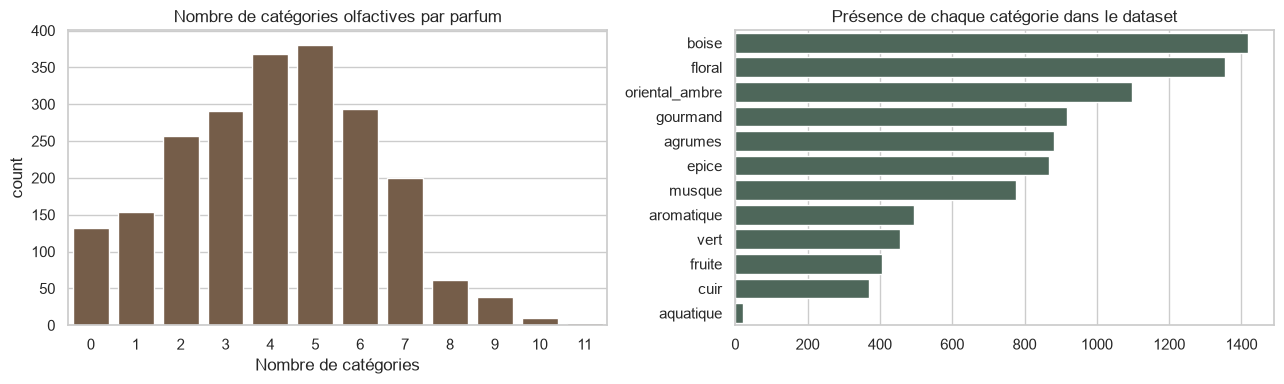

5 exemples :


,Name,notes_list,notes_categories
382,Siberian Rose Eau de Parfum,"[pink pepper, pear, cinnamon, juniper, tuberos...","[floral, epice, vert, fruite, cuir, boise, ori..."
632,Gold Watan Eau de Parfum,"[cistus, oud, nagarmotha, floral notes, musk, ...","[boise, oriental_ambre, musque, gourmand]"
1670,Zagorsk Eau de Toilette,"[white incense, pine, pimento berries, violet,...","[floral, boise, vert]"
211,Rose de Petra Eau de Parfum,"[rose oxide, pomegranate, litchi, bulgarian ro...","[floral, epice, fruite]"
1488,Monserrat Eau de Parfum,"[pink grapefruit, green leaves, carrot seed, o...","[floral, agrumes, vert, boise, musque]"


In [5]:
# Distribution : combien de catégories différentes par parfum, et fréquence de chaque catégorie
nb_categories_par_parfum = df["notes_categories"].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(x=nb_categories_par_parfum, ax=axes[0], color="#7c5c42")
axes[0].set_title("Nombre de catégories olfactives par parfum")
axes[0].set_xlabel("Nombre de catégories")

toutes_categories = Counter(c for liste in df["notes_categories"] for c in liste)
cats, effectifs = zip(*sorted(toutes_categories.items(), key=lambda x: -x[1]))
sns.barplot(x=list(effectifs), y=list(cats), ax=axes[1], color="#4a6b5a")
axes[1].set_title("Présence de chaque catégorie dans le dataset")
plt.tight_layout()
plt.show()

print("5 exemples :")
df[["Name", "notes_list", "notes_categories"]].sample(5, random_state=42)


## 4. `famille` — famille olfactive dominante

Règle : on compte, parmi les notes reconnues du parfum, combien appartiennent
à chaque catégorie. La catégorie avec le plus de notes gagne. En cas
d'égalité, on utilise un ordre de départage explicite : les catégories très
présentes comme **base commune de la plupart des parfums** (`musque`,
`boise`) sont volontairement classées en dernier recours, pour que la
famille dominante reflète ce qui **distingue** le parfum plutôt que son socle
le plus banal. Les familles plus "caractéristiques" (`oriental_ambre`,
`cuir`, `gourmand`...) sont prioritaires en cas d'égalité stricte.

In [6]:
# Ordre de départage en cas d'égalité (du plus prioritaire au moins prioritaire)
PRIORITE_DEPARTAGE_FAMILLE = [
    "oriental_ambre", "cuir", "gourmand", "epice", "aquatique", "fruite",
    "floral", "vert", "aromatique", "agrumes", "boise", "musque",
]


def calculer_famille(notes_brutes):
    """
    Détermine la famille olfactive dominante : la catégorie avec le plus de
    notes reconnues parmi celles du parfum. Égalité tranchée par
    PRIORITE_DEPARTAGE_FAMILLE (catégories "socle" en dernier recours).
    Retourne une chaîne vide si aucune note n'est reconnue.
    """
    reconnues = notes_reconnues(notes_brutes)
    if not reconnues:
        return ""
    compteur = Counter(entree["categorie"] for _, entree in reconnues)
    max_effectif = max(compteur.values())
    categories_ex_aequo = [c for c, n in compteur.items() if n == max_effectif]
    if len(categories_ex_aequo) == 1:
        return categories_ex_aequo[0]
    for categorie in PRIORITE_DEPARTAGE_FAMILLE:
        if categorie in categories_ex_aequo:
            return categorie
    return categories_ex_aequo[0]  # filet de sécurité, ne devrait pas arriver


df["famille"] = df["notes_list"].apply(calculer_famille)


### Validation — `famille`

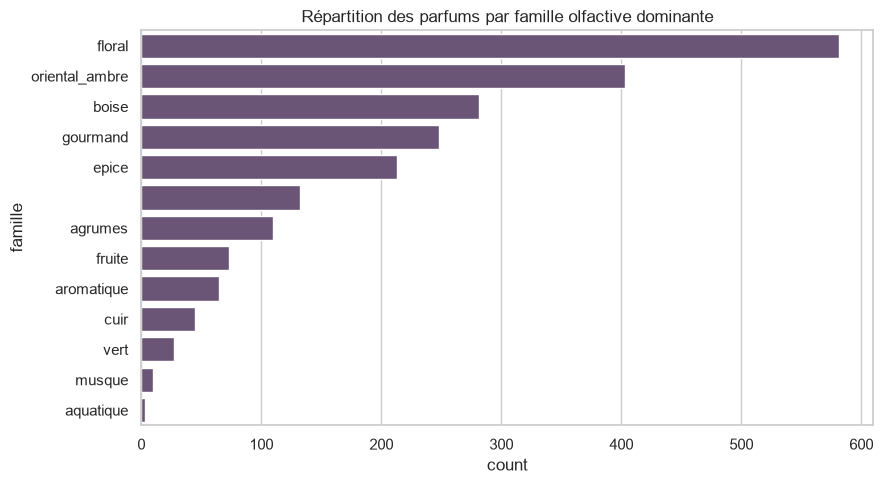

Parfums sans famille détectée (aucune note reconnue) : 132

5 exemples avec le détail du départage :

'Ile Pourpre Eau de Parfum' -> famille = 'oriental_ambre'
  répartition des notes reconnues par catégorie : {'aromatique': 3, 'oriental_ambre': 3, 'agrumes': 1, 'epice': 1, 'fruite': 1, 'floral': 1, 'boise': 2, 'gourmand': 1}

'Number One Intense Eau de Parfum' -> famille = 'floral'
  répartition des notes reconnues par catégorie : {'floral': 5, 'fruite': 1}

'Eshu Extrait' -> famille = 'epice'
  répartition des notes reconnues par catégorie : {'cuir': 3, 'epice': 5, 'oriental_ambre': 2, 'boise': 1, 'vert': 1, 'gourmand': 1}

'Atlante Extrait de Parfum' -> famille = 'floral'
  répartition des notes reconnues par catégorie : {'agrumes': 1, 'aquatique': 1, 'floral': 2, 'epice': 1, 'boise': 1, 'oriental_ambre': 1}

'Lune Feline Eau de Parfum' -> famille = 'oriental_ambre'
  répartition des notes reconnues par catégorie : {'epice': 3, 'boise': 1, 'oriental_ambre': 3, 'gourmand': 1, 'musque

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ordre = df["famille"].value_counts().index
sns.countplot(y=df["famille"], order=ordre, ax=ax, color="#6b4f7c")
ax.set_title("Répartition des parfums par famille olfactive dominante")
plt.tight_layout()
plt.show()

print(f"Parfums sans famille détectée (aucune note reconnue) : {(df['famille'] == '').sum()}")
print("\n5 exemples avec le détail du départage :")
for _, ligne in df.sample(5, random_state=7).iterrows():
    reconnues = notes_reconnues(ligne["notes_list"])
    compteur = Counter(entree["categorie"] for _, entree in reconnues)
    print(f"\n{ligne['Name']!r} -> famille = {ligne['famille']!r}")
    print(f"  répartition des notes reconnues par catégorie : {dict(compteur)}")


## 5. Scores saison / moment (`*_score`)

Moyenne arithmétique simple des scores des notes reconnues (pas de
pondération tête/cœur/fond : cette information n'existe pas dans les
données source — `notes_list` est une liste plate). Si aucune note n'est
reconnue, score neutre par défaut **0.5**, documenté explicitement plutôt que
laissé à `NaN` silencieusement.

In [8]:
SCORE_NEUTRE_PAR_DEFAUT = 0.5


def calculer_score_moyen(notes_brutes, dimension, cle):
    """
    Calcule la moyenne d'un score (ex. dimension="saisons", cle="winter")
    sur les notes reconnues d'un parfum. Fonction générique réutilisée pour
    les 4 scores saisonniers et les 2 scores jour/nuit.
    """
    reconnues = notes_reconnues(notes_brutes)
    if not reconnues:
        return SCORE_NEUTRE_PAR_DEFAUT
    valeurs = [entree[dimension][cle] for _, entree in reconnues]
    return round(sum(valeurs) / len(valeurs), 2)


def expliquer_score(notes_brutes, dimension, cle):
    """
    Retourne le détail note par note ayant produit un score, pour pouvoir
    justifier n'importe quelle valeur (ex. "pourquoi winter_score=0.8 ?").
    """
    reconnues = notes_reconnues(notes_brutes)
    return [(note, entree[dimension][cle]) for note, entree in reconnues]


for saison in ["winter", "spring", "summer", "autumn"]:
    df[f"{saison}_score"] = df["notes_list"].apply(lambda notes: calculer_score_moyen(notes, "saisons", saison))

for moment in ["day", "night"]:
    df[f"{moment}_score"] = df["notes_list"].apply(lambda notes: calculer_score_moyen(notes, "moment", moment))


### Validation — scores saison / jour-nuit

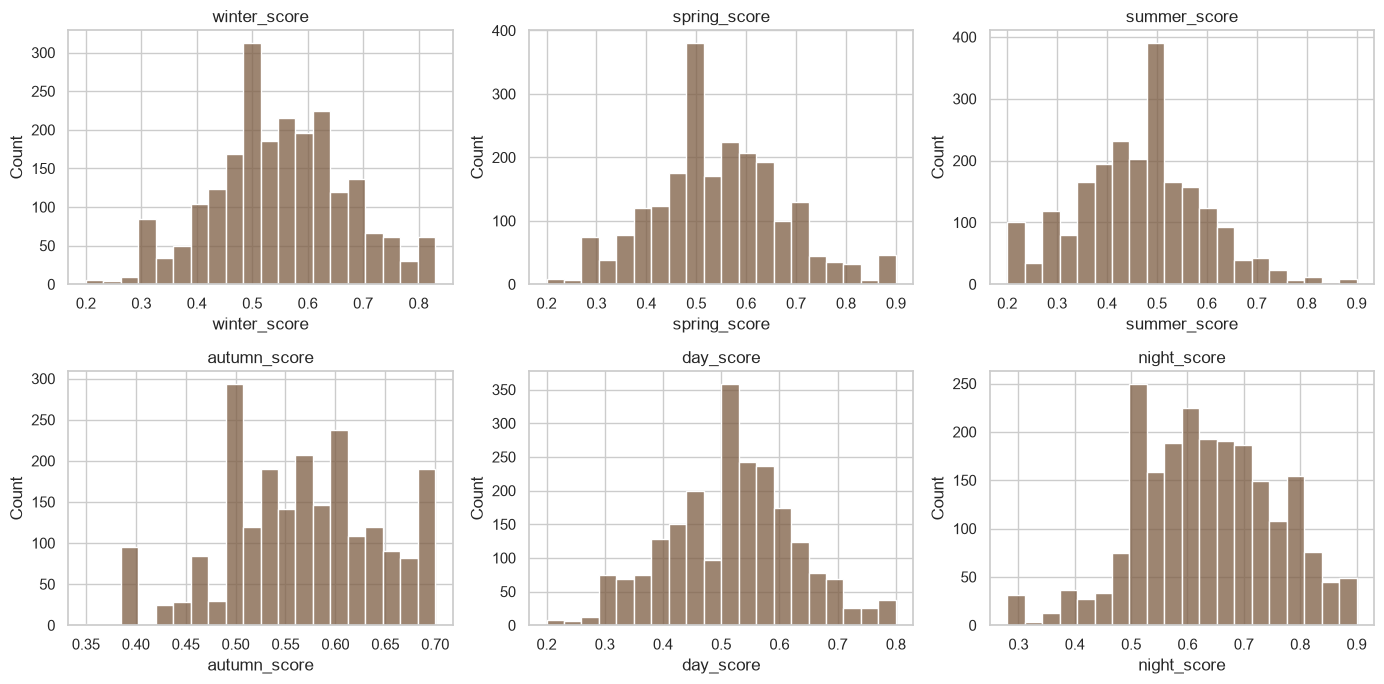

5 exemples avec le détail des notes ayant produit winter_score :

'Pardon Parfum Extrait' -> winter_score = 0.5
  aucune note reconnue -> score neutre par défaut

'Beaute du Diable Eau de Parfum' -> winter_score = 0.48
  détail : lemon=0.3, coriander=0.7, bitter orange=0.3, absinthe=0.4, clove=0.7, cypress=0.3, geranium=0.3, ylang ylang=0.3, carnation=0.3, vetiver=0.7, guaiac wood=0.7, cistus=0.8

'A City On Fire Eau de Parfum' -> winter_score = 0.75
  détail : cardamom=0.7, labdanum=0.8

'Fortis Eau de Parfum' -> winter_score = 0.71
  détail : saffron=0.7, cumin=0.7, oud=0.7, cypriol=0.7, guaiac wood=0.7, cedar=0.7, amyris=0.7, vetiver=0.7, amber=0.8, patchouli=0.7, sandalwood=0.7, vanilla=0.8, musk=0.6

'Knize Ten Golden Edition Eau de Toilette' -> winter_score = 0.49
  détail : petitgrain=0.3, orange=0.3, rosemary=0.4, bergamot=0.3, lemon=0.3, cedar=0.7, sandalwood=0.7, geranium=0.3, iris=0.3, rose=0.3, carnation=0.3, cinnamon=0.7, leather=0.7, ambergris=0.8, musk=0.6, moss=0.3, van

In [9]:
colonnes_scores = ["winter_score", "spring_score", "summer_score", "autumn_score", "day_score", "night_score"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, colonne in zip(axes.flat, colonnes_scores):
    sns.histplot(df[colonne], bins=20, ax=ax, color="#7c5c42")
    ax.set_title(colonne)
plt.tight_layout()
plt.show()

print("5 exemples avec le détail des notes ayant produit winter_score :")
for _, ligne in df.sample(5, random_state=3).iterrows():
    detail = expliquer_score(ligne["notes_list"], "saisons", "winter")
    print(f"\n{ligne['Name']!r} -> winter_score = {ligne['winter_score']}")
    if detail:
        print("  détail :", ", ".join(f"{n}={v}" for n, v in detail))
    else:
        print("  aucune note reconnue -> score neutre par défaut")


## 6. `profil` (masculine / feminine / unisex)

Deux sources de signal, utilisées par ordre de priorité :

1. **Mots-clés explicites** dans le nom + la description (ex. `"masculine"`,
   `"for women"`, `"pour homme"`, `"unisex"`) — trouvés réellement dans les
   données lors de l'inspection (151 mentions de "masculine", 116 de
   "feminine", 84 de "unisex", etc.). Si `"unisex"` est mentionné, il prime
   sur tout le reste. Sinon, on compare le nombre d'indices masculins vs
   féminins.
2. **À défaut de mot-clé**, on retombe sur la moyenne des tendances de
   profil des notes reconnues (`masculine` / `feminine` / `unisex` du
   vocabulaire) et on prend le maximum.

In [10]:
MOTS_CLES_MASCULIN = ["masculine", "for men", "pour homme", " homme", "for him", "men's", " men'"]
MOTS_CLES_FEMININ = ["feminine", "for women", "pour femme", " femme", "for her", "women's", " women'"]
MOT_CLE_UNISEXE = "unisex"


def detecter_profil_texte(nom, description):
    """
    Cherche des indices de genre explicites dans le nom + la description.
    Retourne 'masculine', 'feminine', 'unisex' ou None si aucun indice trouvé.
    """
    texte = f"{nom} {description}".lower()
    if MOT_CLE_UNISEXE in texte:
        return "unisex"
    nb_masculin = sum(1 for mot in MOTS_CLES_MASCULIN if mot in texte)
    nb_feminin = sum(1 for mot in MOTS_CLES_FEMININ if mot in texte)
    if nb_masculin == 0 and nb_feminin == 0:
        return None
    if nb_masculin > nb_feminin:
        return "masculine"
    if nb_feminin > nb_masculin:
        return "feminine"
    return "unisex"  # indices des deux genres présents à parts égales


def calculer_profil(nom, description, notes_brutes):
    """
    Détermine le profil du parfum : priorité aux mots-clés explicites du
    texte source, repli sur la moyenne des tendances de profil des notes
    reconnues si aucun mot-clé n'est trouvé.
    """
    profil_texte = detecter_profil_texte(nom, description)
    if profil_texte is not None:
        return profil_texte

    reconnues = notes_reconnues(notes_brutes)
    if not reconnues:
        return "unisex"  # repli neutre par défaut, documenté

    moyennes = {
        genre: sum(entree["profil"][genre] for _, entree in reconnues) / len(reconnues)
        for genre in ["masculine", "feminine", "unisex"]
    }
    return max(moyennes, key=moyennes.get)


df["profil"] = df.apply(lambda ligne: calculer_profil(ligne["Name"], ligne["Description"], ligne["notes_list"]), axis=1)


### Validation — `profil`

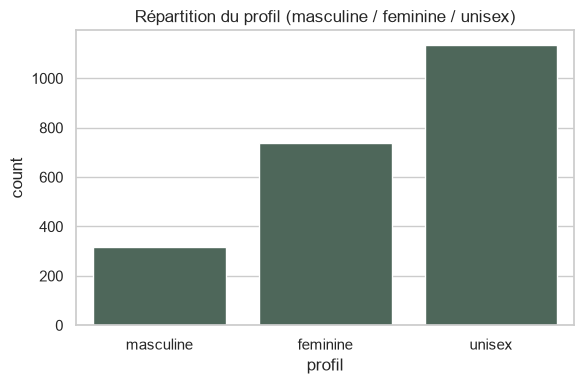

5 exemples avec la méthode de détection utilisée :

'Live In Colors Eau de Parfum' -> profil = 'unisex'  (moyenne des notes (aucun mot-clé trouvé))

'Rose 31 Perfume Oil' -> profil = 'unisex'  (mot-clé explicite du texte)

'Tubereuse Absolue Eau de Parfum' -> profil = 'feminine'  (mot-clé explicite du texte)

'Amyris Pour Homme Eau de Toilette' -> profil = 'masculine'  (mot-clé explicite du texte)

'Patchouli Nobile Eau de Parfum' -> profil = 'unisex'  (moyenne des notes (aucun mot-clé trouvé))


In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=df["profil"], order=["masculine", "feminine", "unisex"], ax=ax, color="#4a6b5a")
ax.set_title("Répartition du profil (masculine / feminine / unisex)")
plt.tight_layout()
plt.show()

print("5 exemples avec la méthode de détection utilisée :")
for _, ligne in df.sample(5, random_state=11).iterrows():
    methode = detecter_profil_texte(ligne["Name"], ligne["Description"])
    origine = "mot-clé explicite du texte" if methode is not None else "moyenne des notes (aucun mot-clé trouvé)"
    print(f"\n{ligne['Name']!r} -> profil = {ligne['profil']!r}  ({origine})")


## 7. `concentration`

Extraction par expression régulière sur le **nom** du parfum, motifs réels
observés dans le dataset (`Eau de Parfum` : 1510 occurrences, `Eau de
Toilette` : 183, `Extrait de Parfum` : 131, `Perfume Oil` : 87, `Attar` : 14,
etc.). Les motifs les plus spécifiques sont testés en premier
(`Extrait de Parfum` avant `Parfum` seul). **Laissée vide si aucun motif ne
correspond** — pas de valeur devinée.

In [12]:
# Ordre = du plus spécifique au plus générique (le premier motif qui matche gagne)
MOTIFS_CONCENTRATION = [
    (r"extrait de parfum", "Extrait de Parfum"),
    (r"eau de parfum", "Eau de Parfum"),
    (r"eau de toilette", "Eau de Toilette"),
    (r"cologne absolue", "Cologne Absolue"),
    (r"eau de cologne", "Eau de Cologne"),
    (r"eau fraiche", "Eau Fraiche"),
    (r"elixir", "Elixir"),
    (r"perfume oil", "Perfume Oil"),
    (r"\battar\b", "Attar"),
    (r"\babsolu\b", "Absolu"),
    (r"\bparfum\b", "Parfum"),
    (r"\bcologne\b", "Cologne"),
]


def extraire_concentration(nom):
    """
    Cherche dans le nom du parfum le premier motif de concentration connu
    (du plus spécifique au plus générique). Retourne une chaîne vide si rien
    n'est détecté, plutôt que de deviner une valeur par défaut.
    """
    nom_minuscule = nom.lower()
    for motif, label in MOTIFS_CONCENTRATION:
        if re.search(motif, nom_minuscule):
            return label
    return ""


df["concentration"] = df["Name"].apply(extraire_concentration)


### Validation — `concentration`

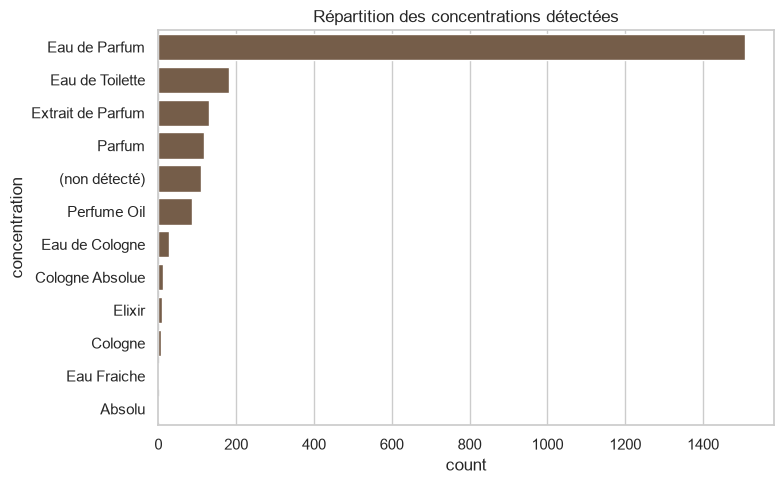

Non détecté : 110 / 2191 parfums

5 exemples détectés :
                            Name     concentration
           Fumidus Eau de Parfum     Eau de Parfum
      Rose de Taif Eau de Parfum     Eau de Parfum
Voix Humaine 8 Extrait de Parfum Extrait de Parfum
      Unutamam Extrait de Parfum Extrait de Parfum
       Ambra Aurea Eau de Parfum     Eau de Parfum

5 exemples NON détectés :
                                  Name concentration
              Gypsy Water Hair Perfume              
    Southern Bloom Perfume Concentrate              
                 Montabaco - Intensivo              
                           Nordic Noir              
Oud Wood Body Spray Scented Body Spray              


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ordre = df["concentration"].replace("", "(non détecté)").value_counts().index
sns.countplot(y=df["concentration"].replace("", "(non détecté)"), order=ordre, ax=ax, color="#7c5c42")
ax.set_title("Répartition des concentrations détectées")
plt.tight_layout()
plt.show()

print(f"Non détecté : {(df['concentration'] == '').sum()} / {len(df)} parfums\n")

print("5 exemples détectés :")
print(df.loc[df["concentration"] != "", ["Name", "concentration"]].sample(5, random_state=1).to_string(index=False))

print("\n5 exemples NON détectés :")
print(df.loc[df["concentration"] == "", ["Name", "concentration"]].sample(5, random_state=1).to_string(index=False))


## 8. `profil_text`

Texte enrichi pour les futurs embeddings (notebook 04) : nom, marque,
famille, notes reconnues et attributs synthétiques, dans une phrase lisible
en langage naturel (utile aussi bien pour l'embedding que pour une
relecture humaine rapide).

In [14]:
def construire_profil_text(ligne):
    """
    Concatène les informations structurées du parfum en un texte enrichi,
    destiné à être vectorisé (embeddings) au notebook suivant.
    """
    reconnues = notes_reconnues(ligne["notes_list"])
    noms_notes = ", ".join(note for note, _ in reconnues) if reconnues else "notes non identifiées"

    saisons = {s: ligne[f"{s}_score"] for s in ["winter", "spring", "summer", "autumn"]}
    saison_dominante = max(saisons, key=saisons.get)
    moment_dominant = "night" if ligne["night_score"] >= ligne["day_score"] else "day"

    famille_txt = ligne["famille"] if ligne["famille"] else "famille non déterminée"
    concentration_txt = f", {ligne['concentration']}" if ligne["concentration"] else ""

    return (
        f"{ligne['Name']} par {ligne['Brand']}{concentration_txt}. "
        f"Famille olfactive : {famille_txt}. "
        f"Notes : {noms_notes}. "
        f"Profil : {ligne['profil']}. "
        f"Saison dominante : {saison_dominante}. Moment : {moment_dominant}."
    )


df["profil_text"] = df.apply(construire_profil_text, axis=1)


### Validation — `profil_text`

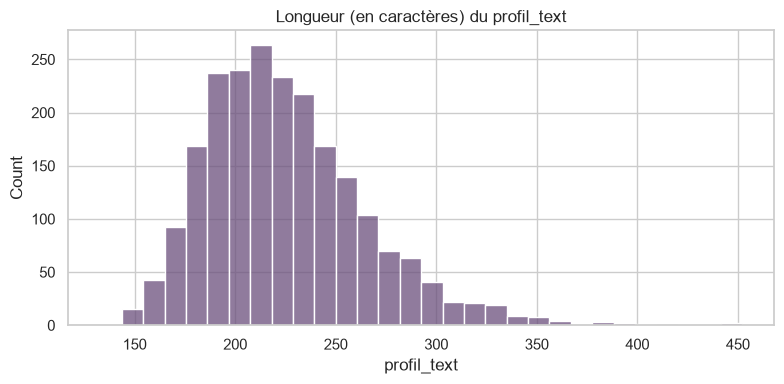

5 exemples complets :
- Siberian Rose Eau de Parfum par Fragrance du Bois, Eau de Parfum. Famille olfactive : floral. Notes : pink pepper, pear, cinnamon, juniper, tuberose, ylang ylang, rose, leather, patchouli, amber, moss. Profil : feminine. Saison dominante : spring. Moment : night.
- Gold Watan Eau de Parfum par ANFAS, Eau de Parfum. Famille olfactive : boise. Notes : cistus, oud, cypriol, musk, sugar. Profil : unisex. Saison dominante : winter. Moment : night.
- Zagorsk Eau de Toilette par Comme des Garcons: Incense, Eau de Toilette. Famille olfactive : floral. Notes : pine, violet, cedar, iris, hinoki. Profil : feminine. Saison dominante : spring. Moment : day.
- Rose de Petra Eau de Parfum par Stephane Humbert Lucas 777, Eau de Parfum. Famille olfactive : epice. Notes : rose oxide, pomegranate, bulgarian rose, pepper, cardamom. Profil : feminine. Saison dominante : spring. Moment : night.
- Monserrat Eau de Parfum par Bruno Fazzolari, Eau de Parfum. Famille olfactive : floral. 

In [15]:
longueurs = df["profil_text"].str.len()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(longueurs, bins=30, ax=ax, color="#6b4f7c")
ax.set_title("Longueur (en caractères) du profil_text")
plt.tight_layout()
plt.show()

print("5 exemples complets :")
for texte in df["profil_text"].sample(5, random_state=42):
    print("-", texte)


## 9. Export vers `nayaar_knowledge_base.csv`

In [16]:
COLONNES_A_EXPORTER = [
    "Name", "Brand", "Description", "Notes", "Image URL",
    "notes_manquantes", "notes_list", "notes_categories", "famille",
    "winter_score", "spring_score", "summer_score", "autumn_score",
    "day_score", "night_score", "profil", "concentration", "profil_text",
]


def exporter_knowledge_base(df, chemin_sortie):
    """
    Exporte la Nayaar Knowledge Base en CSV, encodage UTF-8. Les colonnes
    listes (notes_list, notes_categories) sont sérialisées en JSON, comme au
    notebook 02, pour rester re-parsables (json.loads) dans les notebooks
    suivants (04 embeddings).
    """
    df_export = df[COLONNES_A_EXPORTER].copy()
    df_export["notes_list"] = df_export["notes_list"].apply(json.dumps)
    df_export["notes_categories"] = df_export["notes_categories"].apply(json.dumps)
    df_export.to_csv(chemin_sortie, index=False, encoding="utf-8")


exporter_knowledge_base(df, CHEMIN_SORTIE)
print(f"Knowledge Base exportée : {CHEMIN_SORTIE} ({len(df)} lignes, {len(COLONNES_A_EXPORTER)} colonnes)")


Knowledge Base exportée : ../processed/nayaar_knowledge_base.csv (2191 lignes, 18 colonnes)
